In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
from feature_engineering.weather_data_feature_engineering import engineer_features

FEATURES = [
    "wind_speed_hub_ms",
    "wind_power_density",
    "wind_dir_sin",
    "wind_dir_cos",
    "wind_speed_lag_1h",
    "wind_speed_lag_6h",
    "wind_speed_lag_24h",
    "wind_speed_roll_3h",
    "wind_speed_roll_24h",
    "pressure_hpa",
    "temperature_c",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
]

station_map = {
    "Borssele_12":          "Vlissingen",
    "Borssele_34":          "Vlissingen",
    "Gemini":               "Hoorn",
    "Hollandse_Kust_Zuid":  "Hoek_van_Holland",
    "Hollandse_Kust_Noord": "Hoek_van_Holland",
}

farms_to_train = [
    "Borssele_12",
    "Borssele_34",
    "Gemini",
    "Hollandse_Kust_Zuid",
    "Hollandse_Kust_Noord",
]

results = {}

for farm_id in farms_to_train:
    print(f"\n{'='*60}")
    print(f"Training Decision Tree: {farm_id}")
    print(f"{'='*60}")

    station_id = station_map[farm_id]
    weather_raw = pd.read_csv(
        f"../datasets/knmi_{station_id}.csv",
        parse_dates=["timestamp"]
    )

    # engineer_features expects: timestamp, wind_speed_ms, wind_direction_deg,
    # pressure_hpa, temperature_c, and applies farm-specific hub height scaling
    features = engineer_features(farm_id, weather_raw, return_all_rows=True)

    offshore = pd.read_csv(f"../datasets/offshore_{farm_id}.csv",
                           parse_dates=["time"], index_col="time")

    merged = features.join(offshore[["Power"]], how="inner").dropna()

    X = merged[FEATURES]
    y = merged["Power"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)

    results[farm_id] = {
        "model":     dt,
        "X_test":    X_test,
        "y_test":    y_test,
        "y_pred":    y_pred,
        "mae":       mae,
        "r2":        r2,
        "max_power": y.max(),
    }

    print(f"  Training period: {X_train.index.min()} \u2192 {X_train.index.max()}")
    print(f"  Test period:     {X_test.index.min()} \u2192 {X_test.index.max()}")
    print(f"  MAE: {mae:.2f} MW")
    print(f"  R\u00b2:  {r2:.4f}")
    print(f"  Error as % of max capacity: {(mae/y.max())*100:.1f}%")

print("\n\n" + "="*60)
print("SUMMARY \u2014 Decision Tree Results")
print("="*60)



Training Decision Tree: Borssele_12
  Training period: 2015-01-02 00:00:00 → 2018-12-31 20:00:00
  Test period:     2018-12-31 21:00:00 → 2019-12-31 23:00:00
  MAE: 115.75 MW
  R²:  0.6875
  Error as % of max capacity: 15.4%

Training Decision Tree: Borssele_34
  Training period: 2015-01-02 00:00:00 → 2018-12-31 20:00:00
  Test period:     2018-12-31 21:00:00 → 2019-12-31 23:00:00
  MAE: 117.26 MW
  R²:  0.6639
  Error as % of max capacity: 16.0%

Training Decision Tree: Gemini
  Training period: 2015-01-02 00:00:00 → 2019-01-01 03:00:00
  Test period:     2019-01-01 04:00:00 → 2019-12-31 23:00:00
  MAE: 84.28 MW
  R²:  0.6173
  Error as % of max capacity: 14.0%

Training Decision Tree: Hollandse_Kust_Zuid
  Training period: 2015-01-02 00:00:00 → 2018-12-31 19:00:00
  Test period:     2018-12-31 20:00:00 → 2019-12-31 23:00:00
  MAE: 189.60 MW
  R²:  0.7747
  Error as % of max capacity: 12.4%

Training Decision Tree: Hollandse_Kust_Noord
  Training period: 2015-01-02 00:00:00 → 2018-12

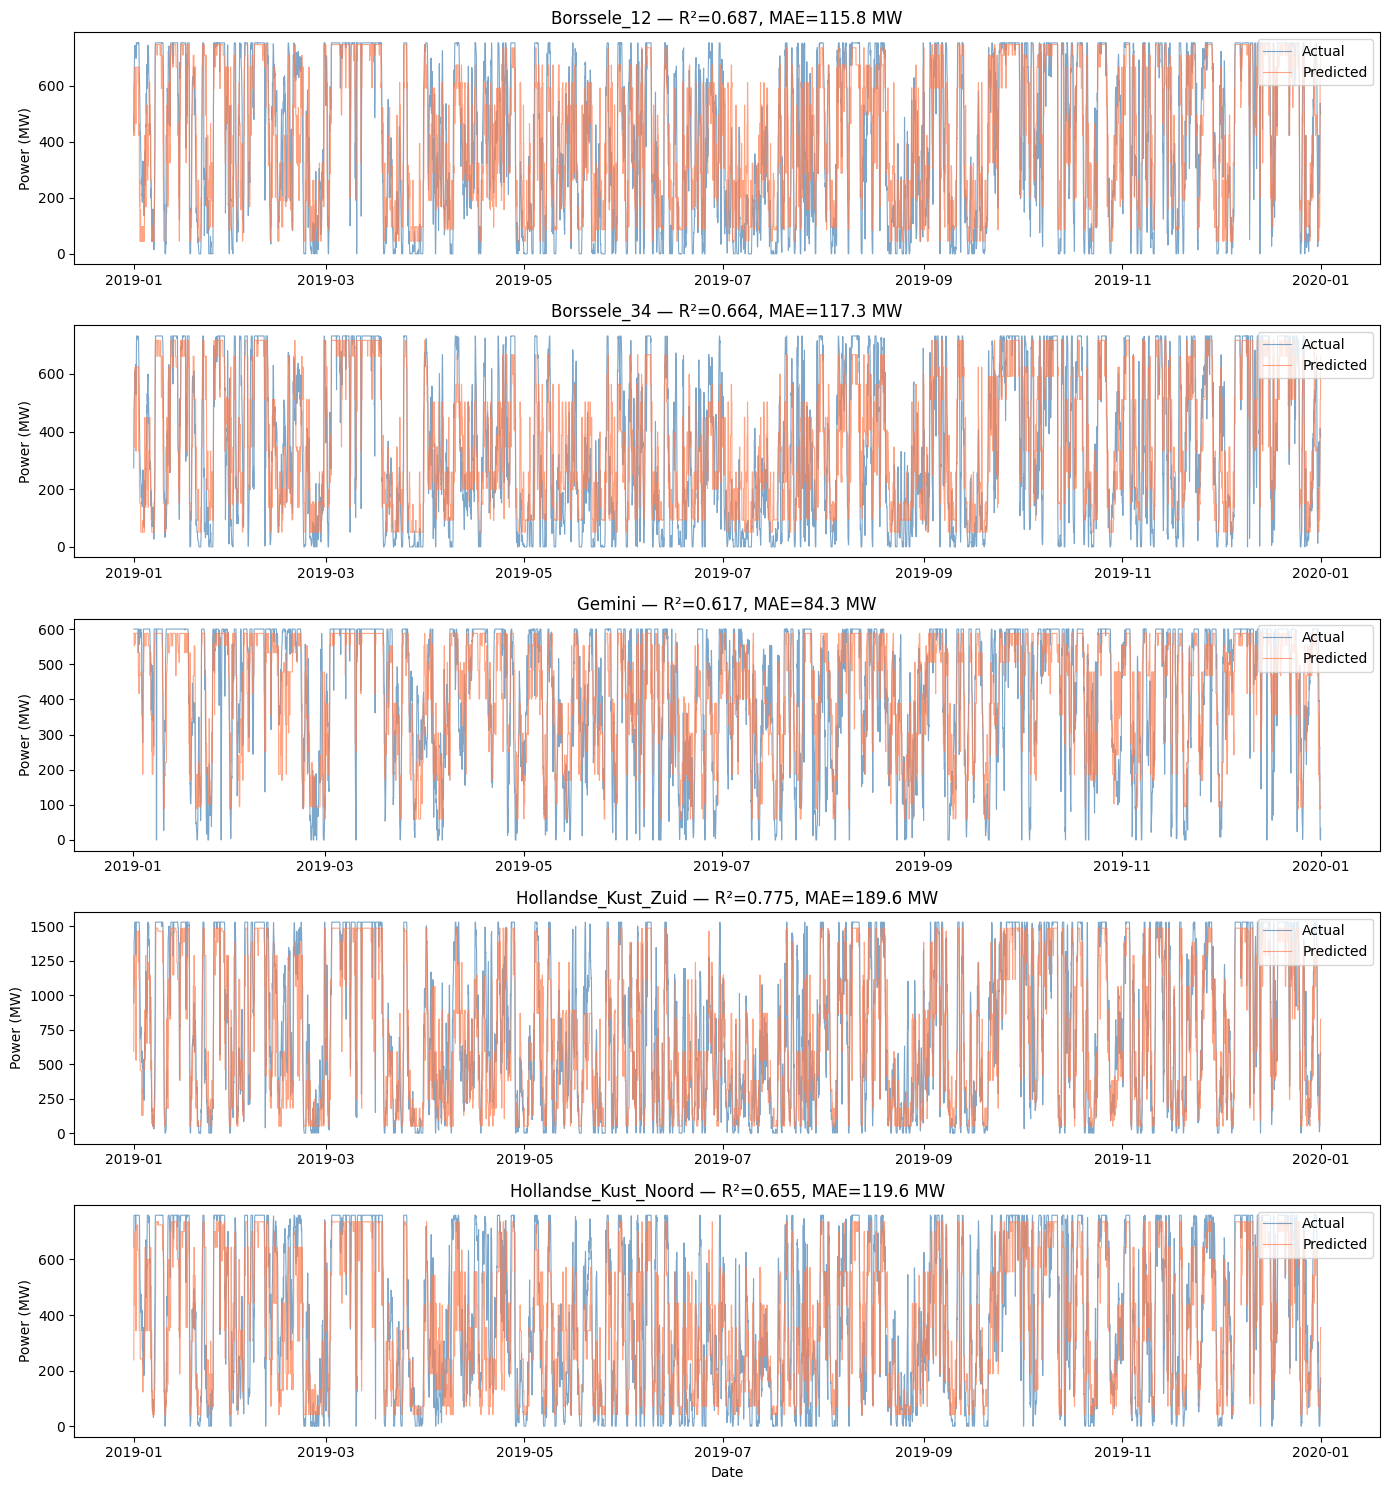

In [3]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 3*len(results)))

for i, (farm_id, r) in enumerate(results.items()):
    axes[i].plot(r["y_test"].index, r["y_test"].values,
                 label="Actual", color="steelblue", alpha=0.7, linewidth=0.8)
    axes[i].plot(r["y_test"].index, r["y_pred"],
                 label="Predicted", color="coral", alpha=0.7, linewidth=0.8)
    axes[i].set_title(f"{farm_id} — R²={r['r2']:.3f}, MAE={r['mae']:.1f} MW")
    axes[i].set_ylabel("Power (MW)")
    axes[i].legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()

plt.show()

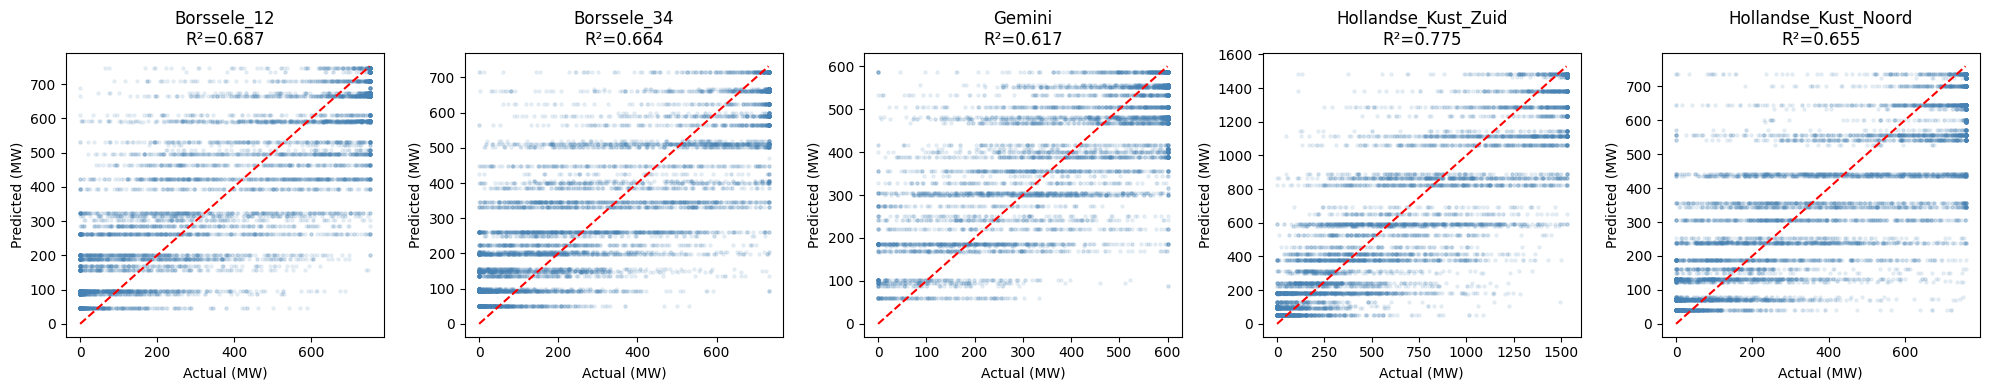

In [4]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))

for i, (farm_id, r) in enumerate(results.items()):
    axes[i].scatter(r["y_test"].values, r["y_pred"], alpha=0.1, s=5, color="steelblue")
    max_val = r["max_power"]
    axes[i].plot([0, max_val], [0, max_val], "r--", linewidth=1.5)
    axes[i].set_title(f"{farm_id}\nR²={r['r2']:.3f}")
    axes[i].set_xlabel("Actual (MW)")
    axes[i].set_ylabel("Predicted (MW)")

plt.tight_layout()
plt.show()

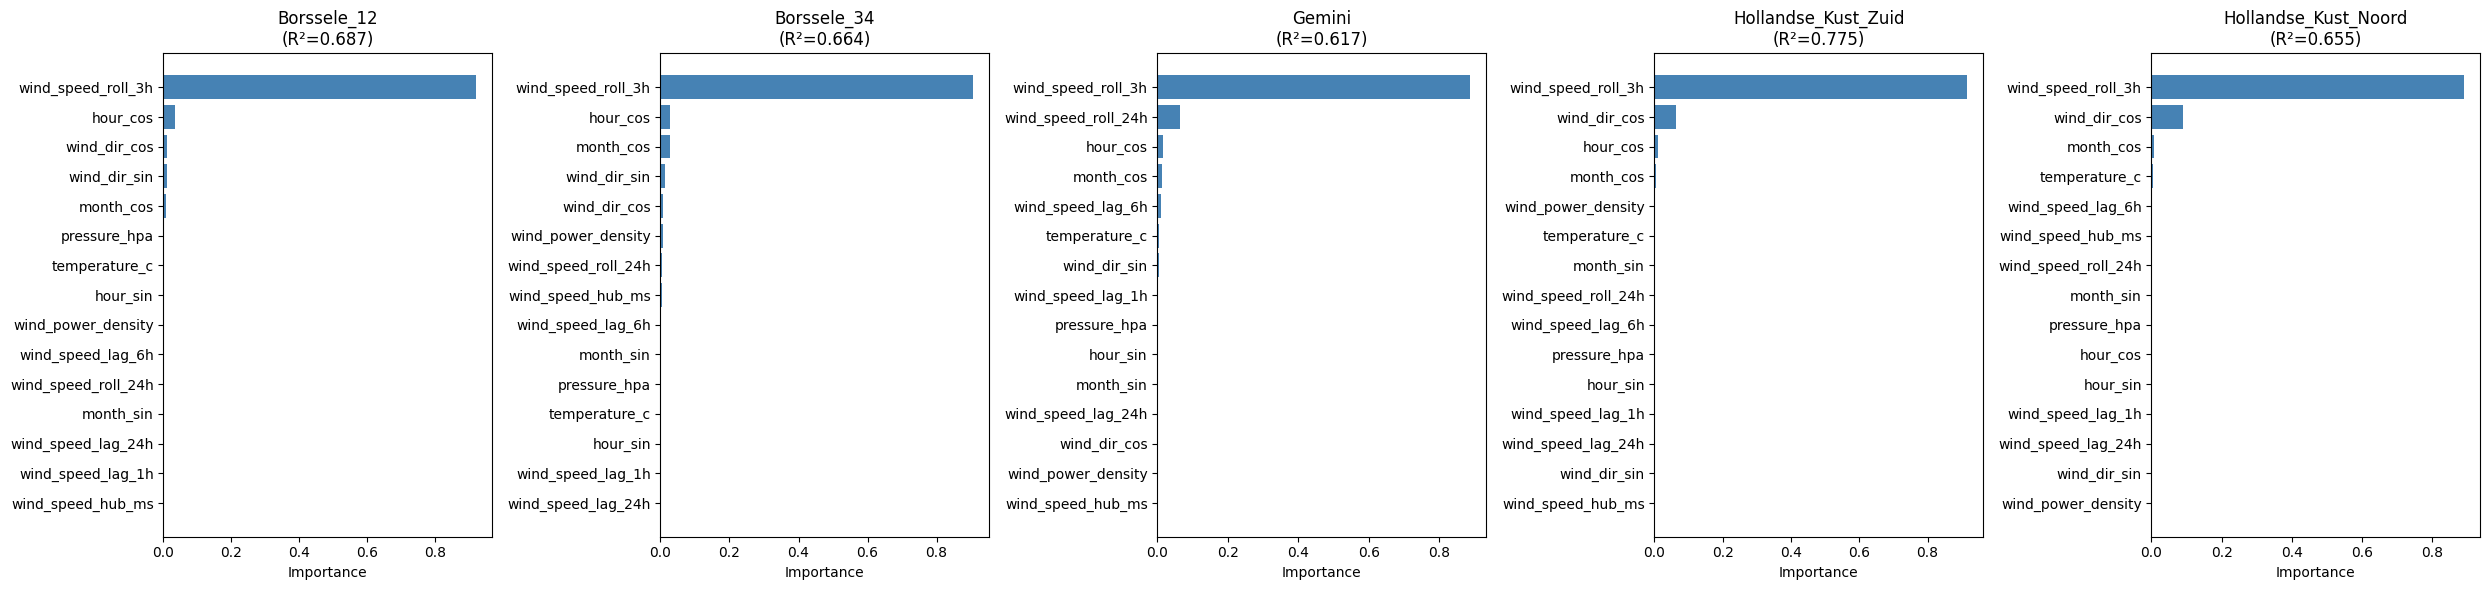

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 6))

for i, (farm_id, r) in enumerate(results.items()):
    importances = pd.Series(
        r["model"].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
    
    axes[i].barh(importances.index, importances.values, color="steelblue")
    axes[i].set_title(f"{farm_id}\n(R²={r['r2']:.3f})")
    axes[i].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [6]:
print("Top 5 Most Important Features per Farm")
print("=" * 60)

for farm_id, r in results.items():
    importances = pd.Series(
        r["model"].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=False)
    
    print(f"\n{farm_id}:")
    for feature, importance in importances.head(5).items():
        print(f"  {feature:<25} {importance:.4f}  ({importance*100:.1f}%)")

Top 5 Most Important Features per Farm

Borssele_12:
  wind_speed_roll_3h        0.9227  (92.3%)
  hour_cos                  0.0350  (3.5%)
  wind_dir_cos              0.0114  (1.1%)
  wind_dir_sin              0.0097  (1.0%)
  month_cos                 0.0084  (0.8%)

Borssele_34:
  wind_speed_roll_3h        0.9067  (90.7%)
  hour_cos                  0.0268  (2.7%)
  month_cos                 0.0262  (2.6%)
  wind_dir_sin              0.0131  (1.3%)
  wind_dir_cos              0.0078  (0.8%)

Gemini:
  wind_speed_roll_3h        0.8885  (88.8%)
  wind_speed_roll_24h       0.0640  (6.4%)
  hour_cos                  0.0156  (1.6%)
  month_cos                 0.0120  (1.2%)
  wind_speed_lag_6h         0.0089  (0.9%)

Hollandse_Kust_Zuid:
  wind_speed_roll_3h        0.9167  (91.7%)
  wind_dir_cos              0.0645  (6.4%)
  hour_cos                  0.0099  (1.0%)
  month_cos                 0.0036  (0.4%)
  wind_power_density        0.0023  (0.2%)

Hollandse_Kust_Noord:
  wind_speed_ro

In [7]:
import joblib
from pathlib import Path

# Create folder for saved models
Path("trained_models").mkdir(parents=True, exist_ok=True)

# Save each trained model
for farm_id, r in results.items():
    path = f"trained_models/decision_tree_{farm_id}.pkl"
    joblib.dump(r["model"], path)
    print(f"Saved → {path}")

Saved → trained_models/decision_tree_Borssele_12.pkl
Saved → trained_models/decision_tree_Borssele_34.pkl
Saved → trained_models/decision_tree_Gemini.pkl
Saved → trained_models/decision_tree_Hollandse_Kust_Zuid.pkl
Saved → trained_models/decision_tree_Hollandse_Kust_Noord.pkl
